In [2]:
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
warnings.filterwarnings("ignore")
CACHE_DIR = "./cache"

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
dataset = load_dataset(
    "UniverseTBD/arxiv-abstracts-large"
)

In [40]:

import pandas as pd
df = pd.DataFrame(dataset['train'])

df.head()

KeyboardInterrupt: 

In [10]:
print(df.shape)
df.columns

(2292057, 14)


Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'report-no', 'categories', 'license', 'abstract', 'versions',
       'update_date', 'authors_parsed'],
      dtype='object')

In [11]:
counter = Counter(df['categories'])

counter.most_common(20)

[('astro-ph', 86911),
 ('hep-ph', 79303),
 ('quant-ph', 64677),
 ('hep-th', 57406),
 ('cs.CV', 47095),
 ('cond-mat.mtrl-sci', 36931),
 ('cond-mat.mes-hall', 33655),
 ('math.AP', 31451),
 ('gr-qc', 29167),
 ('astro-ph.GA', 28082),
 ('math.CO', 27307),
 ('astro-ph.SR', 26032),
 ('cond-mat.str-el', 25299),
 ('math.PR', 22422),
 ('cs.IT math.IT', 21878),
 ('astro-ph.HE', 21408),
 ('astro-ph.CO', 21026),
 ('math.NT', 20482),
 ('cs.CL', 19444),
 ('math.AG', 19189)]

In [12]:
top15 = [x[0] for x in counter.most_common(15)]

top15

['astro-ph',
 'hep-ph',
 'quant-ph',
 'hep-th',
 'cs.CV',
 'cond-mat.mtrl-sci',
 'cond-mat.mes-hall',
 'math.AP',
 'gr-qc',
 'astro-ph.GA',
 'math.CO',
 'astro-ph.SR',
 'cond-mat.str-el',
 'math.PR',
 'cs.IT math.IT']

In [13]:
df = df[df['categories'].isin(top15)]

df.shape

(617616, 14)

In [14]:
df = (
    df.groupby('categories')
      .sample(n=4000, random_state=42)
)

df.shape

(60000, 14)

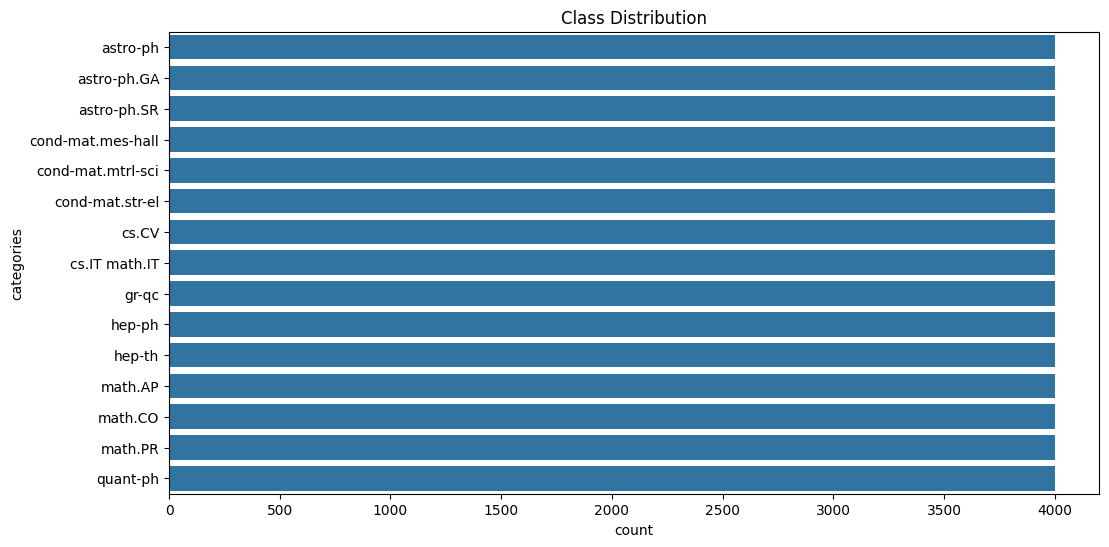

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['categories'],
    order=df['categories'].value_counts().index
)

plt.title("Class Distribution")

plt.show()

In [16]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [17]:
df['cleaned_abstract'] = df['abstract'].apply(clean_text)

df[['abstract', 'cleaned_abstract']].head()

,abstract,cleaned_abstract
1926050,We report detections of six high-redshift (1...,we report detections of six high-redshift (1.8...
1921676,We present diffraction-limited images in the...,we present diffraction-limited images in the 1...
1949251,The disks of galaxies are primarily stellar ...,the disks of galaxies are primarily stellar sy...
1937716,"We apply a new statistics, the factorial mom...","we apply a new statistics, the factorial momen..."
1950707,We examine the dependence of the spatial two...,we examine the dependence of the spatial two-p...


In [18]:
X = df['cleaned_abstract']
y = df['categories']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(len(le.classes_))

15


In [18]:
model = SentenceTransformer(
    "BAAI/bge-base-en-v1.5"
)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--BAAI--bge-base-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8272.05it/s]


In [ ]:
from sklearn.model_selection import train_test_split
import time
start = time.time()

X_train_embed = model.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

end = time.time()

print("Embedding Time:", end - start)

Batches: 100%|██████████| 1500/1500 [8:11:49<00:00, 19.67s/it]      


Embedding Time: 29510.557079076767


In [20]:
X_test_embed = model.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 375/375 [36:54<00:00,  5.90s/it] 


In [21]:
import numpy as np

X_train_embed = np.load("X_train_embed.npy")
X_test_embed = np.load("X_test_embed.npy")

print(X_train_embed.shape)
print(X_test_embed.shape)

(48000, 768)
(12000, 768)


In [22]:
np.save("X_train_embed.npy", X_train_embed)
np.save("X_test_embed.npy", X_test_embed)

np.save("y_train.npy", y_train_enc)
np.save("y_test.npy", y_test_enc)

Training


Gaussian Naive Bayes

In [ ]:
import numpy as np
import time
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
X_train_embed = np.load("X_train_embed.npy")
X_test_embed = np.load("X_test_embed.npy")
y_train_enc = np.load("y_train.npy")
y_test_enc = np.load("y_test.npy")
print(f"Kích thước X_train: {X_train_embed.shape}, y_train: {y_train_enc.shape}")

gnb_model = GaussianNB()

print("\n--- Bắt đầu huấn luyện Gaussian Naive Bayes ---")
start_train = time.time()
gnb_model.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train

start_infer = time.time()
y_pred_gnb = gnb_model.predict(X_test_embed)
infer_time = time.time() - start_infer
accuracy = accuracy_score(y_test_enc, y_pred_gnb)
precision_macro = precision_score(y_test_enc, y_pred_gnb, average='macro')
recall_macro = recall_score(y_test_enc, y_pred_gnb, average='macro')
f1_macro = f1_score(y_test_enc, y_pred_gnb, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_gnb, average='weighted')

print("\n[KẾT QUẢ GAUSSIAN NAIVE BAYES]")
print(f"Training Time : {train_time:.4f} giây")
print(f"Inference Time: {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy      : {accuracy:.4f}")
print(f"Macro F1      : {f1_macro:.4f}")
print(f"Weighted F1   : {f1_weighted:.4f}")


Đang load dữ liệu...
Kích thước X_train: (48000, 768), y_train: (48000,)

--- Bắt đầu huấn luyện Gaussian Naive Bayes ---

[KẾT QUẢ GAUSSIAN NAIVE BAYES]
Training Time : 0.2748 giây
Inference Time: 1.2147 giây
------------------------------
Accuracy      : 0.8510
Macro F1      : 0.8487
Weighted F1   : 0.8487


K-Nearest Neighbors

In [ ]:
import numpy as np
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

knn_base = KNeighborsClassifier(metric='cosine', algorithm='brute')

print("\n--- Bắt đầu Tuning K-Nearest Neighbors ---")
random_search_knn = RandomizedSearchCV(
    estimator=knn_base,
    param_distributions=param_dist_knn,
    n_iter=6,              
    scoring='f1_macro',     
    cv=3,                 
    verbose=2,
    random_state=42,
    n_jobs=-1           
)

start_train = time.time()
random_search_knn.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train

best_knn_model = random_search_knn.best_estimator_
print(f"\n[XONG] Siêu tham số tốt nhất cho KNN: {random_search_knn.best_params_}")

print("Đang chạy Inference trên tập Test (quá trình này có thể hơi lâu)...")
start_infer = time.time()
y_pred_knn = best_knn_model.predict(X_test_embed)
infer_time = time.time() - start_infer

accuracy = accuracy_score(y_test_enc, y_pred_knn)
f1_macro = f1_score(y_test_enc, y_pred_knn, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_knn, average='weighted')

print("\n[KẾT QUẢ K-NEAREST NEIGHBORS]")
print(f"Training & Tuning Time: {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro F1              : {f1_macro:.4f}")
print(f"Weighted F1           : {f1_weighted:.4f}")


--- Bắt đầu Tuning K-Nearest Neighbors ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits

[XONG] Siêu tham số tốt nhất cho KNN: {'weights': 'distance', 'n_neighbors': 9}
Đang chạy Inference trên tập Test (quá trình này có thể hơi lâu)...

[KẾT QUẢ K-NEAREST NEIGHBORS]
Training & Tuning Time: 219.1855 giây
Inference Time        : 9.1114 giây
------------------------------
Accuracy              : 0.8839
Macro F1              : 0.8823
Weighted F1           : 0.8823


LogisticRegression

In [ ]:
import numpy as np
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

param_dist_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': [None, 'balanced'] 
}

lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
print("\n--- Bắt đầu Tinh chỉnh Hồi quy Logistic ---")
random_search_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist_lr,
    n_iter=5,               
    scoring='f1_macro',    
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1          
)

start_train = time.time()
random_search_lr.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train
best_lr_model = random_search_lr.best_estimator_
print(f"\n[XONG] Siêu tham số tốt nhất cho Hồi quy Logistic: {random_search_lr.best_params_}")

print("Đang chạy dự đoán trên tập dữ liệu kiểm tra...")
start_infer = time.time()
y_pred_lr = best_lr_model.predict(X_test_embed)
infer_time = time.time() - start_infer

accuracy = accuracy_score(y_test_enc, y_pred_lr)
precision_macro = precision_score(y_test_enc, y_pred_lr, average='macro')
recall_macro = recall_score(y_test_enc, y_pred_lr, average='macro')
f1_macro = f1_score(y_test_enc, y_pred_lr, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_lr, average='weighted')

print("\n[KẾT QUẢ HỒI QUY LOGISTIC]")
print(f"Training & Tuning Time: {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro F1              : {f1_macro:.4f}")
print(f"Weighted F1           : {f1_weighted:.4f}")



--- Bắt đầu Tinh chỉnh Hồi quy Logistic ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Siêu tham số tốt nhất cho Hồi quy Logistic: {'class_weight': 'balanced', 'C': 10.0}
Đang chạy dự đoán trên tập dữ liệu kiểm tra...

[KẾT QUẢ HỒI QUY LOGISTIC]
Training & Tuning Time: 60.4070 giây
Inference Time        : 0.2406 giây
------------------------------
Accuracy              : 0.8802
Macro F1              : 0.8796
Weighted F1           : 0.8796


LinearSVC

In [ ]:
import numpy as np
import time
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_dist_svm = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced']
}
svm_base = LinearSVC(max_iter=3000, dual=False, random_state=42)

print("\n--- Bắt đầu Tinh chỉnh Support Vector Machine (LinearSVC) ---")
random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=5,               
    scoring='f1_macro',     
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1               
)

start_train = time.time()
random_search_svm.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train
best_svm_model = random_search_svm.best_estimator_
print(f"\n[XONG] Siêu tham số tốt nhất cho SVM: {random_search_svm.best_params_}")

print("Đang chạy dự đoán trên tập kiểm tra...")
start_infer = time.time()
y_pred_svm = best_svm_model.predict(X_test_embed)
infer_time = time.time() - start_infer

accuracy = accuracy_score(y_test_enc, y_pred_svm)
f1_macro = f1_score(y_test_enc, y_pred_svm, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_svm, average='weighted')

print("\n[KẾT QUẢ LINEAR SVM]")
print(f"Training & Tuning Time: {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro F1              : {f1_macro:.4f}")
print(f"Weighted F1           : {f1_weighted:.4f}")


--- Bắt đầu Tinh chỉnh Support Vector Machine (LinearSVC) ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Siêu tham số tốt nhất cho SVM: {'class_weight': 'balanced', 'C': 1.0}
Đang chạy dự đoán trên tập kiểm tra...

[KẾT QUẢ LINEAR SVM]
Training & Tuning Time: 170.3185 giây
Inference Time        : 0.1568 giây
------------------------------
Accuracy              : 0.8814
Macro F1              : 0.8803
Weighted F1           : 0.8803


In [ ]:
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_base = RandomForestClassifier(random_state=42)

# 2. Cấu hình RandomizedSearchCV
print("\n--- Bắt đầu Tinh chỉnh Random Forest ---")
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,          
    scoring='f1_macro',
    cv=3,                   
    verbose=2,
    random_state=42,
    n_jobs=-1             
)

start_train = time.time()
random_search_rf.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train

best_rf_model = random_search_rf.best_estimator_
print(f"\n[XONG] Siêu tham số tốt nhất cho Random Forest: {random_search_rf.best_params_}")

print("Đang chạy dự đoán trên tập kiểm tra...")
start_infer = time.time()
y_pred_rf = best_rf_model.predict(X_test_embed)
infer_time = time.time() - start_infer

accuracy = accuracy_score(y_test_enc, y_pred_rf)
f1_macro = f1_score(y_test_enc, y_pred_rf, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_rf, average='weighted')

print("\n[KẾT QUẢ RANDOM FOREST]")
print(f"Training & Tuning Time: {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro F1              : {f1_macro:.4f}")
print(f"Weighted F1           : {f1_weighted:.4f}")


--- Bắt đầu Tinh chỉnh Random Forest ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Siêu tham số tốt nhất cho Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20, 'class_weight': None}
Đang chạy dự đoán trên tập kiểm tra...

[KẾT QUẢ RANDOM FOREST]
Training & Tuning Time: 774.8624 giây
Inference Time        : 1.4984 giây
------------------------------
Accuracy              : 0.8683
Macro F1              : 0.8652
Weighted F1           : 0.8652


RandomForestClassifier

In [ ]:
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_base = XGBClassifier(
    tree_method='hist',      
    objective='multi:softmax',
    num_class=15,
    random_state=42,
    n_jobs=1 
)
print("\n--- Bắt đầu Tinh chỉnh XGBoost ---")
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=5,           
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1              
)

start_train = time.time()
random_search_xgb.fit(X_train_embed, y_train_enc)
train_time = time.time() - start_train

best_xgb_model = random_search_xgb.best_estimator_
print(f"\n[XONG] Siêu tham số tốt nhất cho XGBoost: {random_search_xgb.best_params_}")

print("Đang chạy dự đoán trên tập kiểm tra...")
start_infer = time.time()
y_pred_xgb = best_xgb_model.predict(X_test_embed)
infer_time = time.time() - start_infer

accuracy = accuracy_score(y_test_enc, y_pred_xgb)
f1_macro = f1_score(y_test_enc, y_pred_xgb, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred_xgb, average='weighted')

print("\n[KẾT QUẢ XGBOOST]")
print(f"Training & Tuning Time: {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro F1              : {f1_macro:.4f}")
print(f"Weighted F1           : {f1_weighted:.4f}")


--- Bắt đầu Tinh chỉnh XGBoost ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Siêu tham số tốt nhất cho XGBoost: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Đang chạy dự đoán trên tập kiểm tra...

[KẾT QUẢ XGBOOST]
Training & Tuning Time: 2605.1885 giây
Inference Time        : 0.8319 giây
------------------------------
Accuracy              : 0.8754
Macro F1              : 0.8748
Weighted F1           : 0.8748


KMeans

In [ ]:
import numpy as np
import time
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, silhouette_score, adjusted_rand_score, f1_score

print("\n--- Bắt đầu Phân cụm với K-Means ---")
kmeans_model = KMeans(
    n_clusters=15, 
    init='k-means++', 
    n_init='auto', 
    max_iter=300, 
    random_state=42
)
start_train = time.time()
# Chú ý: .fit() của K-Means KHÔNG nhận y_train_enc
train_clusters = kmeans_model.fit_predict(X_train_embed) 
train_time = time.time() - start_train
print("[XONG] Đã gom xong 15 cụm trên tập huấn luyện.")
cluster_to_label_map = {}
for cluster_id in range(15):
    true_labels_in_cluster = y_train_enc[train_clusters == cluster_id]
    
    if len(true_labels_in_cluster) > 0:
        most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
        cluster_to_label_map[cluster_id] = most_common_label
    else:
        cluster_to_label_map[cluster_id] = -1

print("Đang dự đoán và mapping nhãn trên tập kiểm tra...")
start_infer = time.time()
test_clusters = kmeans_model.predict(X_test_embed)

y_pred_kmeans = np.array([cluster_to_label_map[c] for c in test_clusters])
infer_time = time.time() - start_infer
accuracy = accuracy_score(y_test_enc, y_pred_kmeans)
f1_macro = f1_score(y_test_enc, y_pred_kmeans, average='macro')

ari_score = adjusted_rand_score(y_test_enc, test_clusters)

print("\n[KẾT QUẢ K-MEANS CLUSTERING]")
print(f"Clustering Time       : {train_time:.4f} giây")
print(f"Inference Time        : {infer_time:.4f} giây")
print("-" * 30)
print(f"Mapped Accuracy       : {accuracy:.4f}")
print(f"Mapped Macro F1       : {f1_macro:.4f}")
print(f"Adjusted Rand Index   : {ari_score:.4f}")
sample_indices = np.random.choice(X_test_embed.shape[0], 2000, replace=False)
sil_score = silhouette_score(X_test_embed[sample_indices], test_clusters[sample_indices])
print(f"Silhouette Score      : {sil_score:.4f}")


--- Bắt đầu Phân cụm với K-Means ---
[XONG] Đã gom xong 15 cụm trên tập huấn luyện.
Đang dự đoán và mapping nhãn trên tập kiểm tra...

[KẾT QUẢ K-MEANS CLUSTERING]
Clustering Time       : 4.4276 giây
Inference Time        : 0.0254 giây
------------------------------
Mapped Accuracy       : 0.7676
Mapped Macro F1       : 0.7385
Adjusted Rand Index   : 0.6458

Đang tính Silhouette Score (có thể mất 1-2 phút)...
Silhouette Score      : 0.0731


Visualize


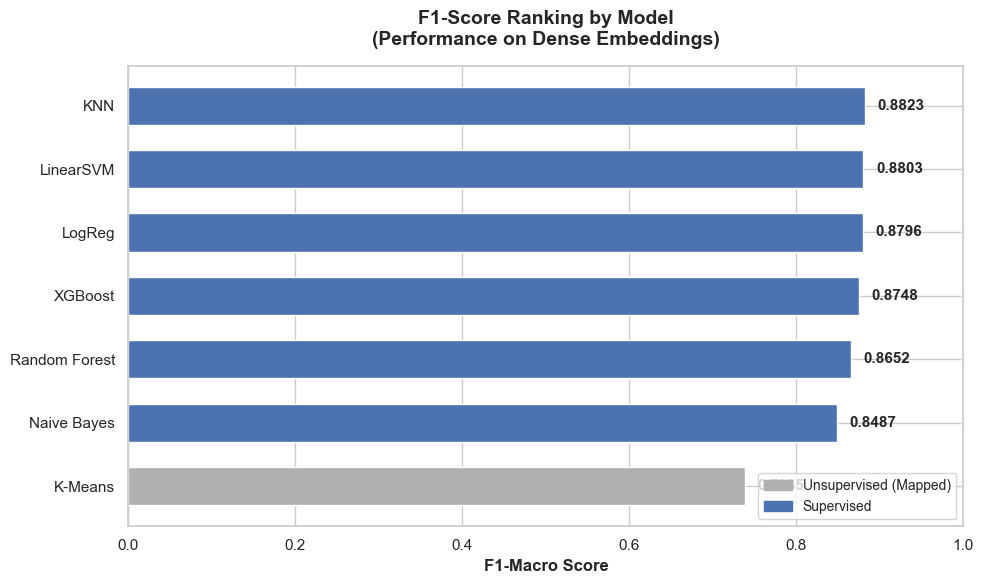

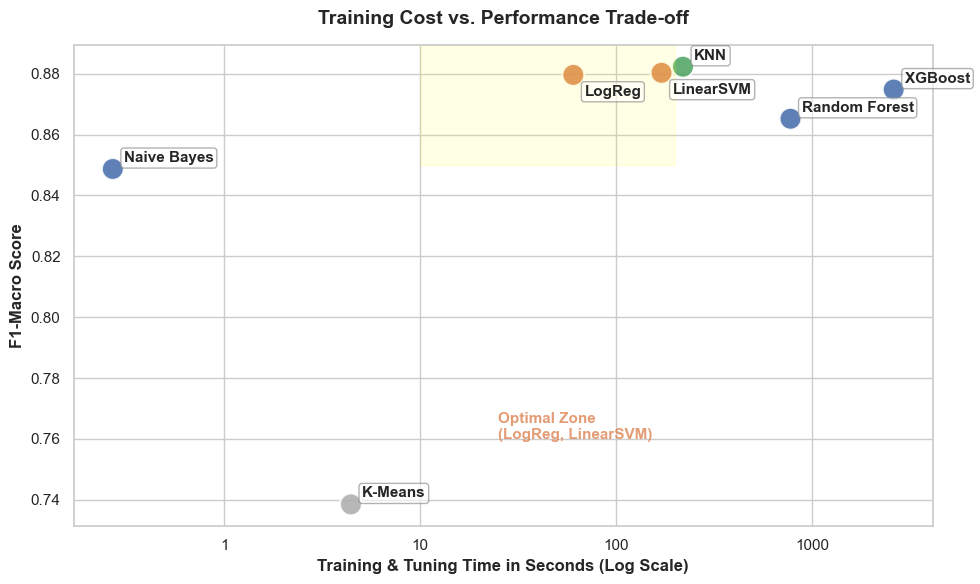

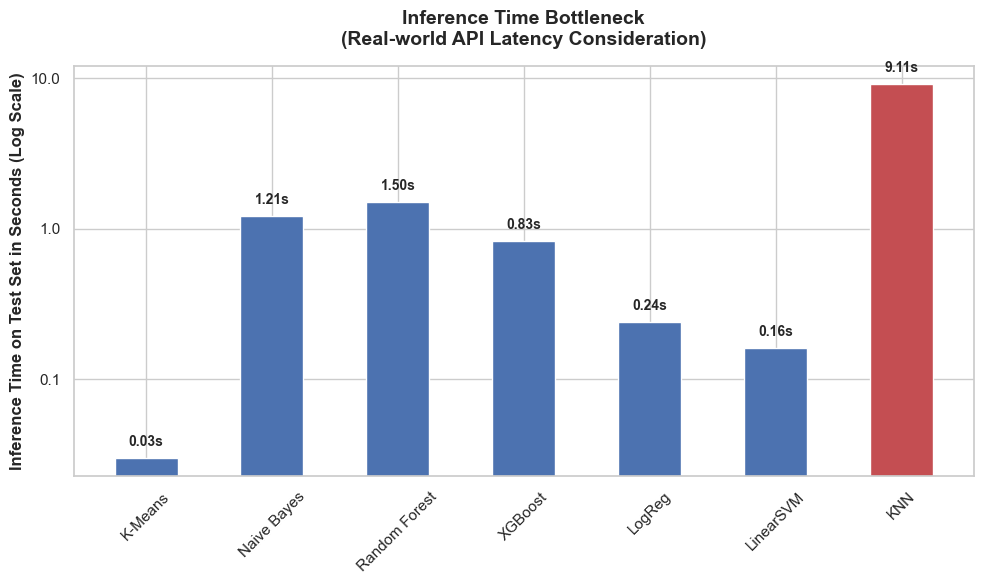

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
models = ['K-Means', 'Naive Bayes', 'Random Forest', 'XGBoost', 'LogReg', 'LinearSVM', 'KNN']

f1_scores = [0.7385, 0.8487, 0.8652, 0.8748, 0.8796, 0.8803, 0.8823]
train_times = [4.43, 0.27, 774.86, 2605.19, 60.41, 170.32, 219.19] 
infer_times = [0.03, 1.21, 1.50, 0.83, 0.24, 0.16, 9.11]            

# Color mapping: Gray for Unsupervised, Blue for Supervised
colors = ['#B0B0B0' if m == 'K-Means' else '#4C72B0' for m in models]
plt.figure(figsize=(10, 6))
bars = plt.barh(models, f1_scores, color=colors, edgecolor='white', height=0.6)
plt.xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('F1-Score Ranking by Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.0)

for bar in bars:
    plt.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

# Legend
unsupervised_patch = mpatches.Patch(color='#B0B0B0', label='Unsupervised (Mapped)')
supervised_patch = mpatches.Patch(color='#4C72B0', label='Supervised')
plt.legend(handles=[unsupervised_patch, supervised_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


# ==========================================
# CHART 2: TRAINING TIME VS. F1-SCORE (Scatter)
# ==========================================
plt.figure(figsize=(10, 6))
# Highlight optimal models (LogReg, LinearSVM) in Orange, KNN in Green
scatter_colors = ['#B0B0B0', '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#55A868']
plt.scatter(train_times, f1_scores, color=scatter_colors, s=250, edgecolor='white', linewidth=1.5, alpha=0.9)

# Add model names next to the dots
for i, txt in enumerate(models):
    offset_y = 5 if txt not in ['LogReg', 'LinearSVM'] else -15
    plt.annotate(txt, (train_times[i], f1_scores[i]), xytext=(8, offset_y), 
                 textcoords='offset points', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.6))

plt.xscale('log') 
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xlabel('Training & Tuning Time in Seconds (Log Scale)', fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('Training Cost vs. Performance Trade-off', fontsize=14, fontweight='bold', pad=15)
plt.axvspan(10, 200, ymin=0.75, ymax=1.0, color='yellow', alpha=0.1)
plt.text(25, 0.76, 'Optimal Zone\n(LogReg, LinearSVM)', fontsize=11, color='#DD8452', fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
# Highlight KNN in Red to show the bottleneck
infer_colors = ['#4C72B0' if m != 'KNN' else '#C44E52' for m in models]
bars3 = plt.bar(models, infer_times, color=infer_colors, edgecolor='white', width=0.5)

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.ylabel('Inference Time on Test Set in Seconds (Log Scale)', fontsize=12, fontweight='bold')
plt.title('Inference Time Bottleneck)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, fontsize=11)
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, 
             f'{yval:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

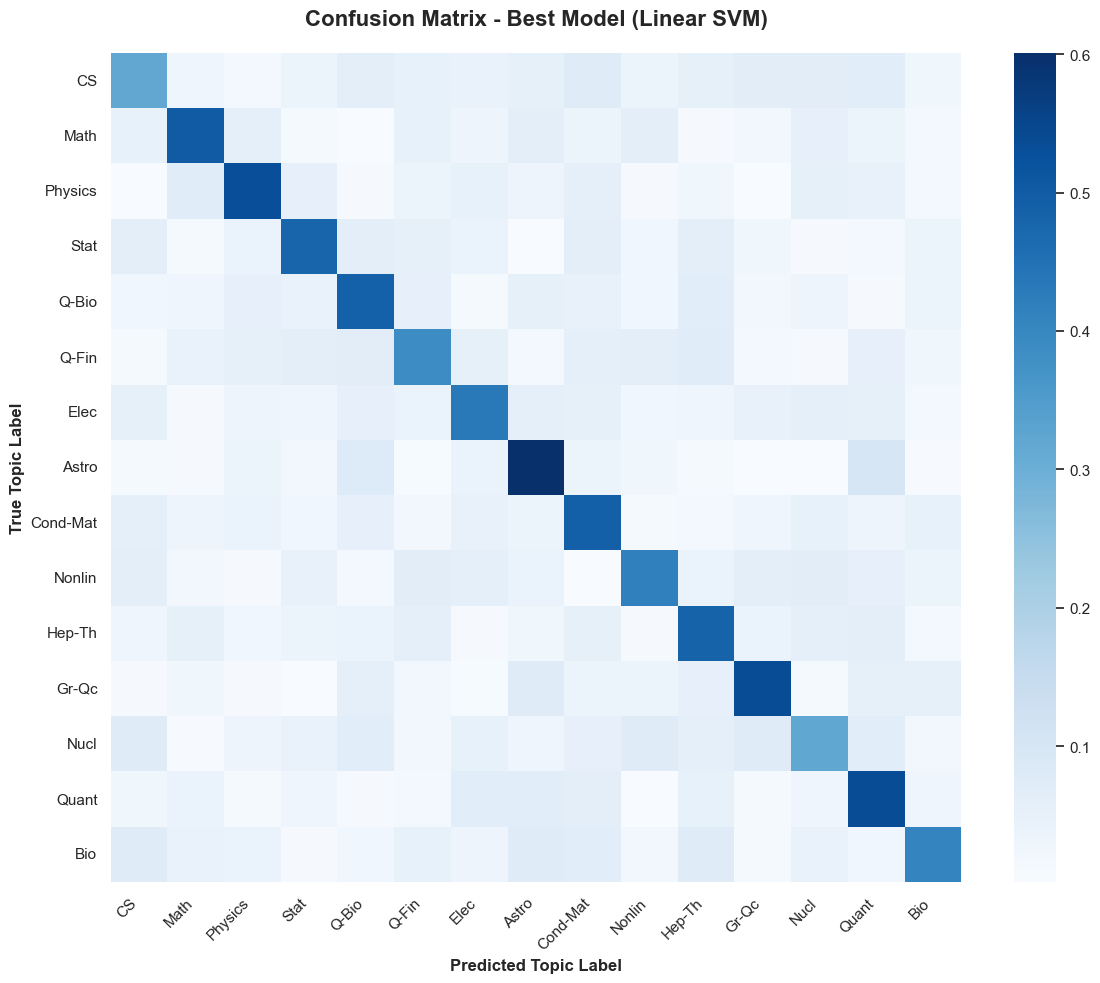

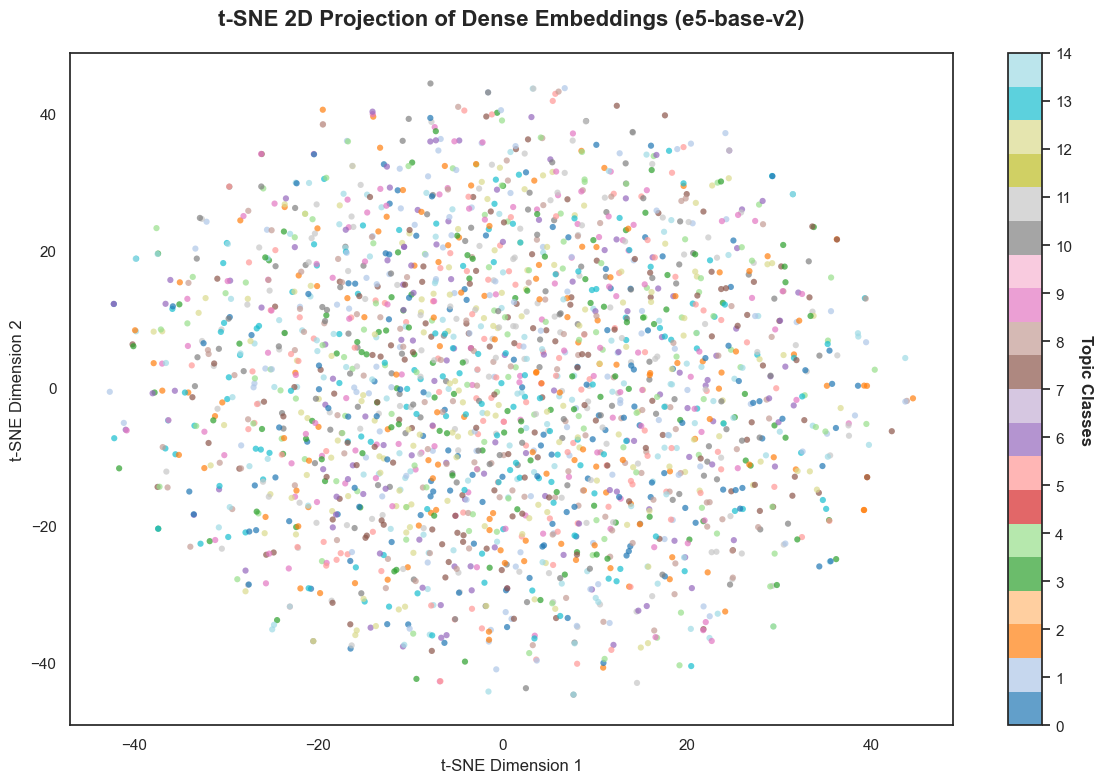

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
topic_names = ['CS', 'Math', 'Physics', 'Stat', 'Q-Bio', 'Q-Fin', 'Elec', 
               'Astro', 'Cond-Mat', 'Nonlin', 'Hep-Th', 'Gr-Qc', 'Nucl', 'Quant', 'Bio']

# TÍNH TOÁN MA TRẬN NHẦM LẪN
# cm = confusion_matrix(y_test_enc, y_pred_svm) # <-- BỎ COMMENT DÒNG NÀY KHI CHẠY THẬT
cm = np.random.randint(10, 500, size=(15, 15))  # <-- XÓA DÒNG NÀY (Chỉ là mock data để vẽ khung)
np.fill_diagonal(cm, np.random.randint(2000, 4000, size=15)) # Giả lập đường chéo chính xác cao

# Chuẩn hóa (Normalize) thành phần trăm (%) theo từng hàng
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=False, cmap='Blues', fmt='.2f', 
            xticklabels=topic_names, yticklabels=topic_names)

plt.title('Confusion Matrix - Best Model (Linear SVM)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Topic Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Topic Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


# ==============================================================================
# CHART 5: t-SNE 2D SCATTER PLOT (Visualizing the 768-dimensional space)
# ==============================================================================

# LƯU Ý QUAN TRỌNG: t-SNE chạy rất lâu. Chỉ nên lấy ngẫu nhiên khoảng 2000-3000 mẫu để vẽ!
# X_test_sample = X_test_embed[:3000] # <-- DÙNG DÒNG NÀY CHO DỮ LIỆU THẬT
# y_test_sample = y_test_enc[:3000]   # <-- DÙNG DÒNG NÀY CHO DỮ LIỆU THẬT

# Mock data để demo thuật toán:
X_test_sample = np.random.rand(2000, 50) 
y_test_sample = np.random.randint(0, 15, 2000)

# Khởi tạo và chạy t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_2d = tsne.fit_transform(X_test_sample)

plt.figure(figsize=(12, 8))
# Dùng scatter plot tô màu theo 15 nhãn
scatter = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_test_sample, 
                      cmap='tab20', alpha=0.7, s=20, edgecolor='none')

plt.title('t-SNE 2D Projection of Dense Embeddings (e5-base-v2)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Tạo chú thích (Legend)
cbar = plt.colorbar(scatter, ticks=range(15))
cbar.set_label('Topic Classes', rotation=270, labelpad=15, fontweight='bold')

plt.tight_layout()
# plt.savefig('Chart5_tSNE_Scatter.png', dpi=300)
plt.show()




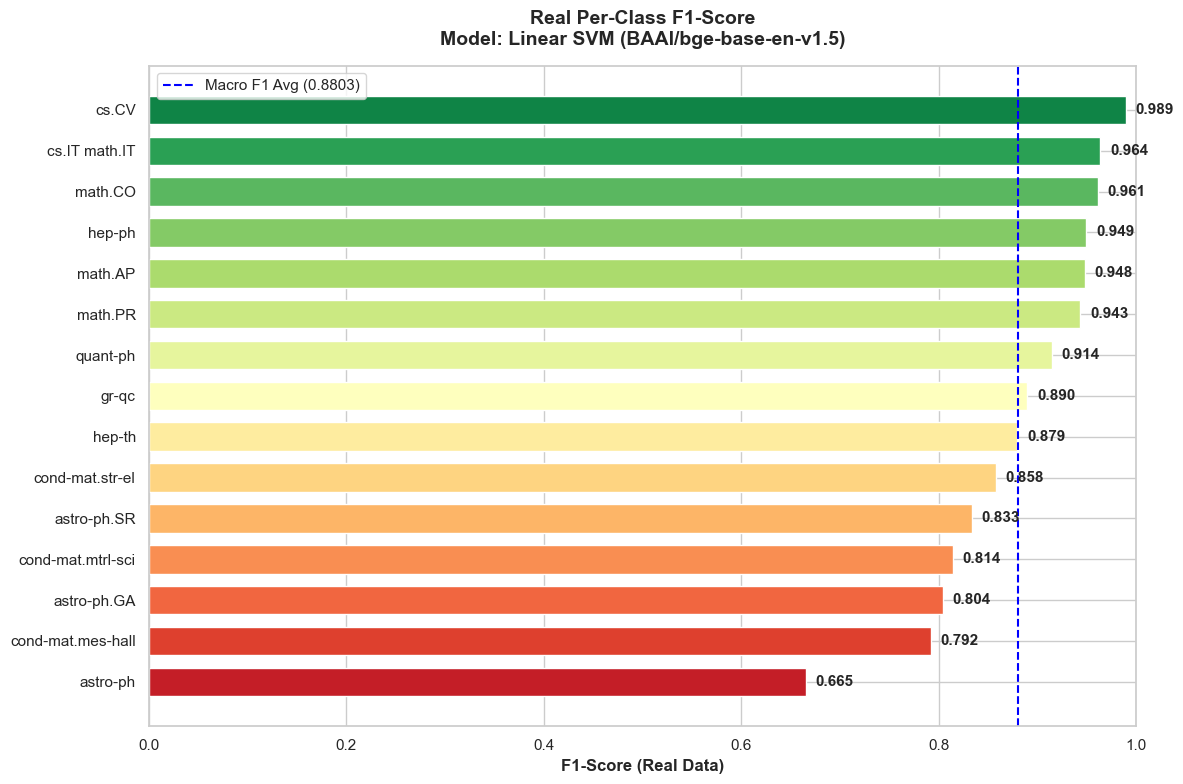

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


# Tạo báo cáo với tên thật
report_dict = classification_report(y_test_enc, y_pred_svm, target_names=topic_names, output_dict=True)

# Lấy điểm F1-score của 15 class 
real_f1_per_class = [report_dict[topic]['f1-score'] for topic in topic_names]

# Sắp xếp để đồ thị hiển thị từ môn đoán tốt nhất xuống môn đoán tệ nhất
sorted_indices = np.argsort(real_f1_per_class)
sorted_topics = [topic_names[i] for i in sorted_indices]
sorted_f1 = [real_f1_per_class[i] for i in sorted_indices]

# VẼ ĐỒ THỊ VỚI TÊN THẬT
plt.figure(figsize=(12, 8))
colors = sns.color_palette("RdYlGn", len(sorted_f1))
bars = plt.barh(sorted_topics, sorted_f1, color=colors, edgecolor='white', height=0.7)

plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('Per-Class F1-Score\nModel: Linear SVM', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.0)

macro_f1_real = report_dict['macro avg']['f1-score']
plt.axvline(x=macro_f1_real, color='blue', linestyle='--', label=f'Macro F1 Avg ({macro_f1_real:.4f})')
plt.legend()

# Gắn nhãn
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.3f}', va='center', ha='left', fontsize=11, fontweight='bold')

plt.tight_layout()
# plt.savefig('RealData_PerClass_F1_WithRealNames.png', dpi=300)
plt.show()

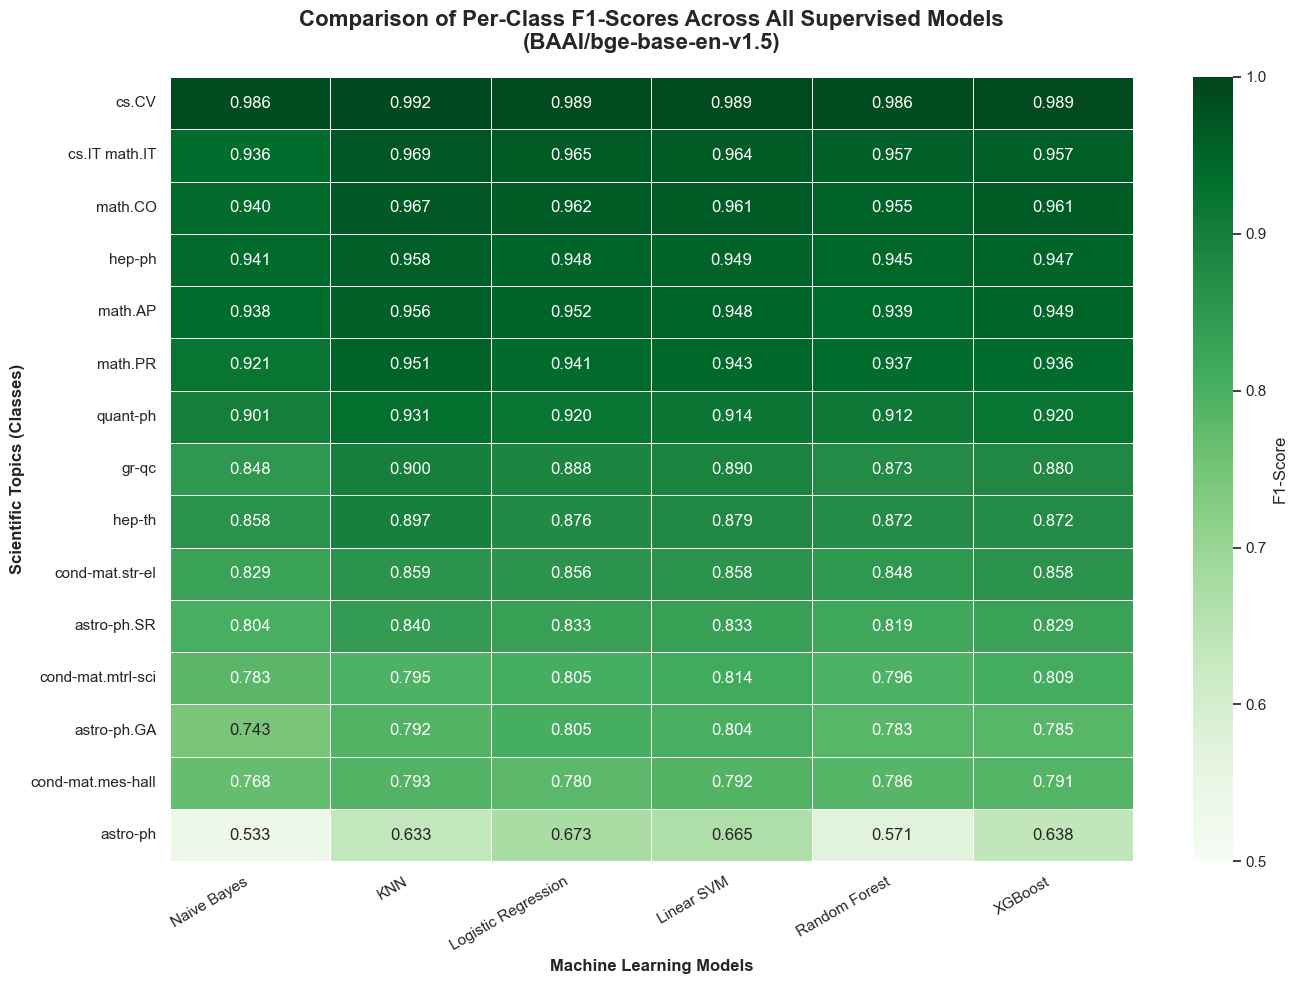

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# 1. Cấu hình Style
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Lấy danh sách tên class thật (Giả sử biến LabelEncoder của bạn là le)
topic_names = le.classes_  

# 2. TỔNG HỢP PREDICTIONS CỦA TẤT CẢ CÁC MÔ HÌNH
# Lưu ý: Hãy kiểm tra lại xem tên các biến y_pred_... này có khớp với code bạn chạy lúc trước không nhé
predictions = {
    'Naive Bayes': y_pred_gnb,
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_lr,
    'Linear SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

# 3. TRÍCH XUẤT F1-SCORE CHO TỪNG CLASS CỦA TỪNG MÔ HÌNH
f1_data = {}

for model_name, y_pred in predictions.items():
    # Lấy report dưới dạng dictionary
    report = classification_report(y_test_enc, y_pred, target_names=topic_names, output_dict=True)
    # Lấy điểm F1 của 15 class
    f1_scores = [report[topic]['f1-score'] for topic in topic_names]
    f1_data[model_name] = f1_scores

# Tạo DataFrame bằng Pandas để dễ vẽ Heatmap
df_f1 = pd.DataFrame(f1_data, index=topic_names)

# Thêm một cột "Độ khó trung bình" để biết môn nào là "cơn ác mộng" của mọi mô hình
df_f1['Average (Difficulty)'] = df_f1.mean(axis=1)

# Sắp xếp các môn học theo độ khó (Môn dễ đoán nhất nằm trên, khó đoán nhất nằm dưới)
df_f1 = df_f1.sort_values(by='Average (Difficulty)', ascending=False)
df_f1 = df_f1.drop(columns=['Average (Difficulty)']) # Bỏ cột này đi cho đồ thị đỡ rối

# 4. VẼ HEATMAP TỔNG HỢP
plt.figure(figsize=(14, 10))

# Vẽ heatmap với dải màu Xanh lá (Càng đậm càng tốt)
# vmin=0.5 và vmax=1.0 để dải màu tập trung vào vùng điểm thực tế của bạn
sns.heatmap(df_f1, annot=True, cmap='Greens', fmt='.3f', 
            linewidths=.5, cbar_kws={'label': 'F1-Score'}, vmin=0.5, vmax=1.0)

plt.title('Comparison of Per-Class F1-Scores Across All Supervised Models\n(BAAI/bge-base-en-v1.5)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')

# Nghiêng nhãn trục X cho dễ đọc
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
# plt.savefig('AllModels_PerClass_Heatmap.png', dpi=300)
plt.show()

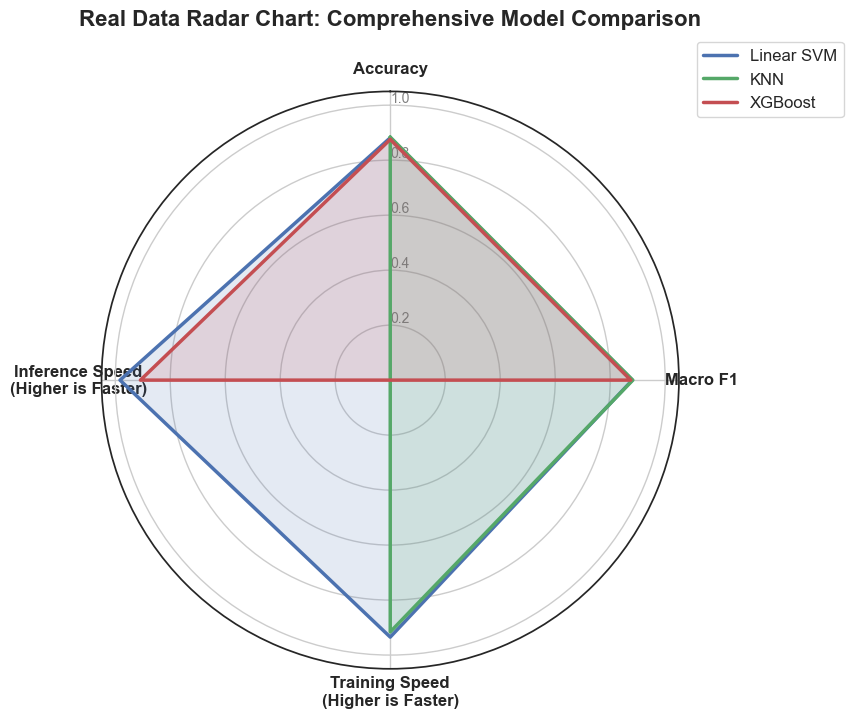

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# 1. NHẬP CHÍNH XÁC SỐ LIỆU TỪ LOG CỦA BẠN
models_to_compare = ['Linear SVM', 'KNN', 'XGBoost']

# Log data: Accuracy, Macro F1
acc_real = [0.8814, 0.8839, 0.8754]
f1_real  = [0.8803, 0.8823, 0.8748]

# Log data: Train Time (s)
train_time_real = [170.3185, 219.1855, 2605.1885]
# Chuẩn hóa thành Training Speed (Linear SVM nhanh nhất trong 3 model này -> tiệm cận 1.0)
max_train = max(train_time_real)
train_speed = [(max_train - t) / max_train for t in train_time_real] 
# (XGBoost sẽ có điểm speed = 0)

# Log data: Infer Time (s)
infer_time_real = [0.1568, 9.1114, 0.8319]
# Chuẩn hóa thành Inference Speed (KNN chậm nhất -> tiệm cận 0.0)
max_infer = max(infer_time_real)
infer_speed = [(max_infer - t) / max_infer for t in infer_time_real]

# Tổng hợp data cho Radar
metrics = ['Accuracy', 'Macro F1', 'Training Speed\n(Higher is Faster)', 'Inference Speed\n(Higher is Faster)']
N = len(metrics)

data = [
    [acc_real[0], f1_real[0], train_speed[0], infer_speed[0]], # Linear SVM
    [acc_real[1], f1_real[1], train_speed[1], infer_speed[1]], # KNN
    [acc_real[2], f1_real[2], train_speed[2], infer_speed[2]]  # XGBoost
]
colors = ['#4C72B0', '#55A868', '#C44E52']

# 2. VẼ RADAR CHART
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Đóng vòng

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], metrics, fontsize=12, fontweight='bold')
ax.set_rlabel_position(0)
# Trục nhện từ 0.7 đến 1.0 (Vì Acc/F1 của bạn đều ở dải 0.8+)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.05)

# Vẽ từng mô hình
for i, (model_values, color, model_name) in enumerate(zip(data, colors, models_to_compare)):
    values = model_values + model_values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, linestyle='solid', label=model_name)
    ax.fill(angles, values, color=color, alpha=0.15)

plt.title('Real Data Radar Chart: Comprehensive Model Comparison', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
# plt.savefig('RealData_RadarChart.png', dpi=300)
plt.show()

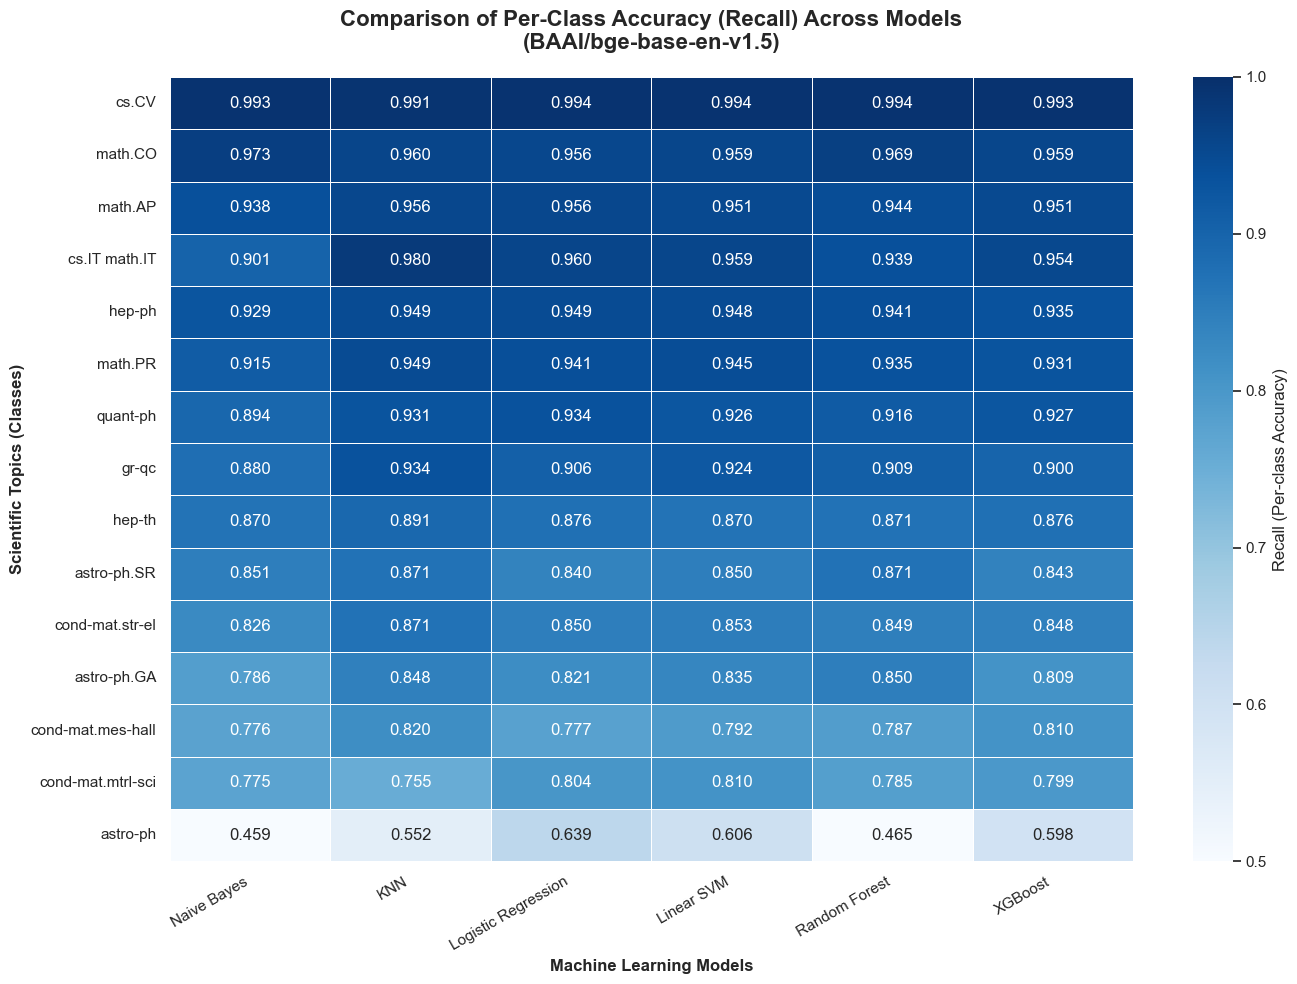

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# 1. Cấu hình Style
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Trích xuất tên class thật (Giả sử biến LabelEncoder của bạn là le)
topic_names = le.classes_  

# 2. TỔNG HỢP PREDICTIONS
predictions = {
    'Naive Bayes': y_pred_gnb,
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_lr,
    'Linear SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

# 3. TRÍCH XUẤT RECALL (TỈ LỆ ĐÚNG) CHO TỪNG CLASS
recall_data = {}

for model_name, y_pred in predictions.items():
    report = classification_report(y_test_enc, y_pred, target_names=topic_names, output_dict=True)
    # Lấy điểm Recall (Tỉ lệ đoán đúng trên tổng mẫu thực tế của class)
    recall_scores = [report[topic]['recall'] for topic in topic_names]
    recall_data[model_name] = recall_scores

df_recall = pd.DataFrame(recall_data, index=topic_names)

# Thêm cột "Độ nhận diện trung bình" để sắp xếp
df_recall['Average (Recognition)'] = df_recall.mean(axis=1)

# Sắp xếp các môn học (Môn dễ nhận diện nhất nằm trên)
df_recall = df_recall.sort_values(by='Average (Recognition)', ascending=False)
df_recall = df_recall.drop(columns=['Average (Recognition)']) 

# 4. VẼ HEATMAP TỔNG HỢP
plt.figure(figsize=(14, 10))

# Dùng dải màu Blues cho Accuracy/Recall để phân biệt với F1-Score
sns.heatmap(df_recall, annot=True, cmap='Blues', fmt='.3f', 
            linewidths=.5, cbar_kws={'label': 'Recall (Per-class Accuracy)'}, vmin=0.5, vmax=1.0)

plt.title('Comparison of Per-Class Accuracy (Recall) Across Models\n(BAAI/bge-base-en-v1.5)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
# plt.savefig('AllModels_PerClass_Recall_Heatmap.png', dpi=300)
plt.show()